 # 📌 1. Imports


In [45]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier #library for random forest
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
import seaborn as sns

# 📌 2. Load Dataset


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
#loading the dataset
data = pd.read_csv("/content/processed_features (2).csv")

 📌 3. Displaying the Data


In [48]:
data

,Status of existing checking account,Duration in month,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,foreign worker,Status
0,... < 0 DM,0.029412,critical account/ other credits existing (not ...,radio/television,0.050567,unknown/ no savings account,>= 7 years,1.000000,male : single,none,...,real estate,0.857143,none,own,0.333333,skilled employee / official,0,"yes, registered under the customers name",yes,1
1,0 <= ... < 200 DM,0.647059,existing credits paid back duly till now,radio/television,0.313690,... < 100 DM,1 <= ... < 4 years,0.333333,female : divorced/separated/married,none,...,real estate,0.053571,none,own,0.000000,skilled employee / official,0,none,yes,0
2,no checking account,0.117647,critical account/ other credits existing (not ...,education,0.101574,... < 100 DM,4 <= ... < 7 years,0.333333,male : single,none,...,real estate,0.535714,none,own,0.000000,unskilled - resident,1,none,yes,1
3,... < 0 DM,0.558824,existing credits paid back duly till now,furniture/equipment,0.419941,... < 100 DM,4 <= ... < 7 years,0.333333,male : single,guarantor,...,building society savings agreement/ life insur...,0.464286,none,for free,0.000000,skilled employee / official,1,none,yes,1
4,... < 0 DM,0.294118,delay in paying off in the past,car (new),0.254209,... < 100 DM,1 <= ... < 4 years,0.666667,male : single,none,...,unknown / no property,0.607143,none,for free,0.333333,skilled employee / official,1,none,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,0.117647,existing credits paid back duly till now,furniture/equipment,0.081765,... < 100 DM,4 <= ... < 7 years,0.666667,female : divorced/separated/married,none,...,real estate,0.214286,none,own,0.000000,unskilled - resident,0,none,yes,1
996,... < 0 DM,0.382353,existing credits paid back duly till now,car (used),0.198470,... < 100 DM,1 <= ... < 4 years,1.000000,male : divorced/separated,none,...,building society savings agreement/ life insur...,0.375000,none,own,0.000000,management/ self-employed/ highly qualified em...,0,"yes, registered under the customers name",yes,1
997,no checking account,0.117647,existing credits paid back duly till now,radio/television,0.030483,... < 100 DM,>= 7 years,1.000000,male : single,none,...,"car or other, not in attribute 6",0.339286,none,own,0.000000,skilled employee / official,0,none,yes,0
998,... < 0 DM,0.602941,existing credits paid back duly till now,radio/television,0.087763,... < 100 DM,1 <= ... < 4 years,1.000000,male : single,none,...,unknown / no property,0.071429,none,for free,0.000000,skilled employee / official,0,"yes, registered under the customers name",yes,1


# 📌 3. Basic Preprocessing  
### ✔ Drop unwanted columns  



In [49]:
data = data.drop(columns=['Status of existing checking account'])  # Removing the unique identifier
data = pd.get_dummies(data, columns=['Credit history', 'Purpose','Savings account/bonds' ,'Present employment since','Personal status and sex', 'Other debtors / guarantors', 'Property','Other installment plans','Housing','Job','Telephone','foreign worker'])  # One-hot encoding categorical variables

In [50]:
data

,Duration in month,Credit amount,Installment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Status,Credit history_all credits at this bank paid back duly,Credit history_critical account/ other credits existing (not at this bank),...,Housing_own,Housing_rent,Job_management/ self-employed/ highly qualified employee/ officer,Job_skilled employee / official,Job_unemployed/ unskilled - non-resident,Job_unskilled - resident,Telephone_none,"Telephone_yes, registered under the customers name",foreign worker_no,foreign worker_yes
0,0.029412,0.050567,1.000000,1.000000,0.857143,0.333333,0,1,False,True,...,True,False,False,True,False,False,False,True,False,True
1,0.647059,0.313690,0.333333,0.333333,0.053571,0.000000,0,0,False,False,...,True,False,False,True,False,False,True,False,False,True
2,0.117647,0.101574,0.333333,0.666667,0.535714,0.000000,1,1,False,True,...,True,False,False,False,False,True,True,False,False,True
3,0.558824,0.419941,0.333333,1.000000,0.464286,0.000000,1,1,False,False,...,False,False,False,True,False,False,True,False,False,True
4,0.294118,0.254209,0.666667,1.000000,0.607143,0.333333,1,1,False,False,...,False,False,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.117647,0.081765,0.666667,1.000000,0.214286,0.000000,0,1,False,False,...,True,False,False,False,False,True,True,False,False,True
996,0.382353,0.198470,1.000000,1.000000,0.375000,0.000000,0,1,False,False,...,True,False,True,False,False,False,False,True,False,True
997,0.117647,0.030483,1.000000,1.000000,0.339286,0.000000,0,0,False,False,...,True,False,False,True,False,False,True,False,False,True
998,0.602941,0.087763,1.000000,1.000000,0.071429,0.000000,0,1,False,False,...,False,False,False,True,False,False,False,True,False,True


# 📌 4. Handle Missing Values  
### ✔ Separate X and y  
### ✔ Numeric imputation  


In [51]:
X = data.drop(columns=['Status'])
y = data['Status']


# 📌 6. Exploratory Plots  



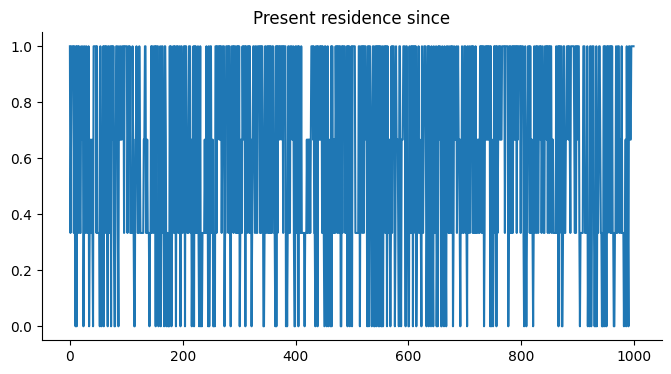

In [52]:
from matplotlib import pyplot as plt
data['Present residence since'].plot(kind='line', figsize=(8, 4), title='Present residence since')
plt.gca().spines[['top', 'right']].set_visible(False)

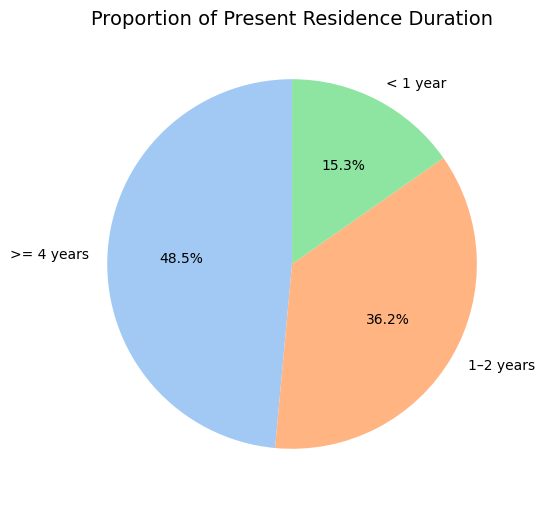

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your data
data = pd.read_csv("processed_features (2).csv")

# Map encoded numeric values to human-readable labels
# You can adjust this mapping based on your dataset
residence_mapping = {
    0.0: '< 1 year',
    0.3333333333333333: '1–2 years',
    0.6666666666666666: '2–3 years',
    1.0: '>= 4 years'
}

# Replace encoded values with readable text
data['Present residence since'] = data['Present residence since'].map(residence_mapping)

# Create pie chart
plt.figure(figsize=(6,6))
data['Present residence since'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel'),
    labels=data['Present residence since'].value_counts().index
)
plt.title('Proportion of Present Residence Duration', fontsize=14)
plt.ylabel('')
plt.show()


/tmp/ipython-input-463986360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Present residence since', y='Credit amount', data=data, palette='coolwarm')


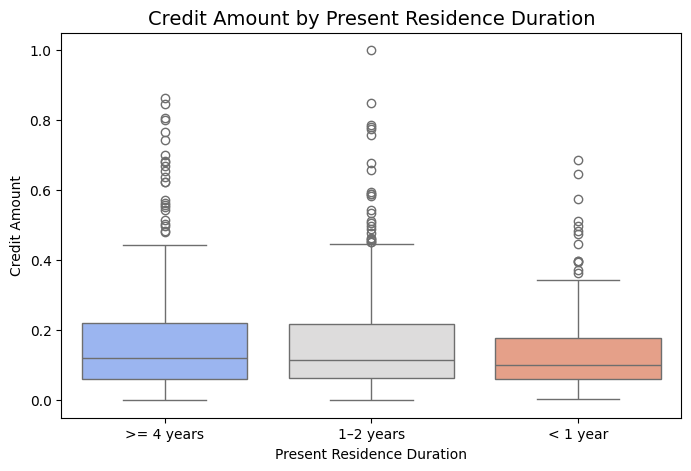

In [54]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Present residence since', y='Credit amount', data=data, palette='coolwarm')
plt.title('Credit Amount by Present Residence Duration', fontsize=14)
plt.xlabel('Present Residence Duration')
plt.ylabel('Credit Amount')
plt.show()


/tmp/ipython-input-372106409.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Housing', y='Credit amount', data=data, palette='Set2', estimator='mean')


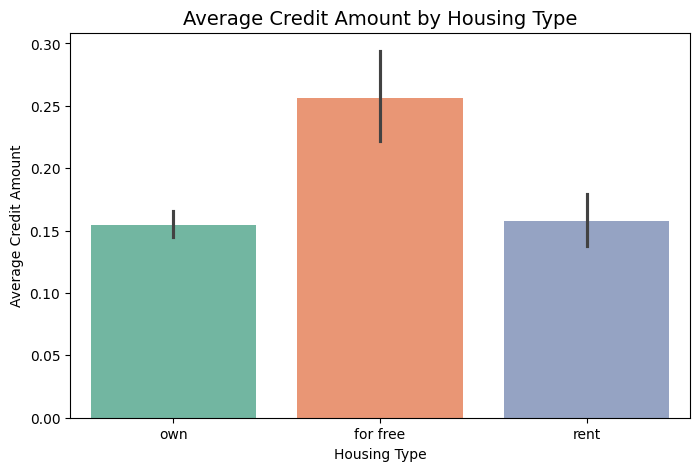

In [55]:
if 'Housing' in data.columns:
    plt.figure(figsize=(8,5))
    sns.barplot(x='Housing', y='Credit amount', data=data, palette='Set2', estimator='mean')
    plt.title('Average Credit Amount by Housing Type', fontsize=14)
    plt.ylabel('Average Credit Amount')
    plt.xlabel('Housing Type')
    plt.show()


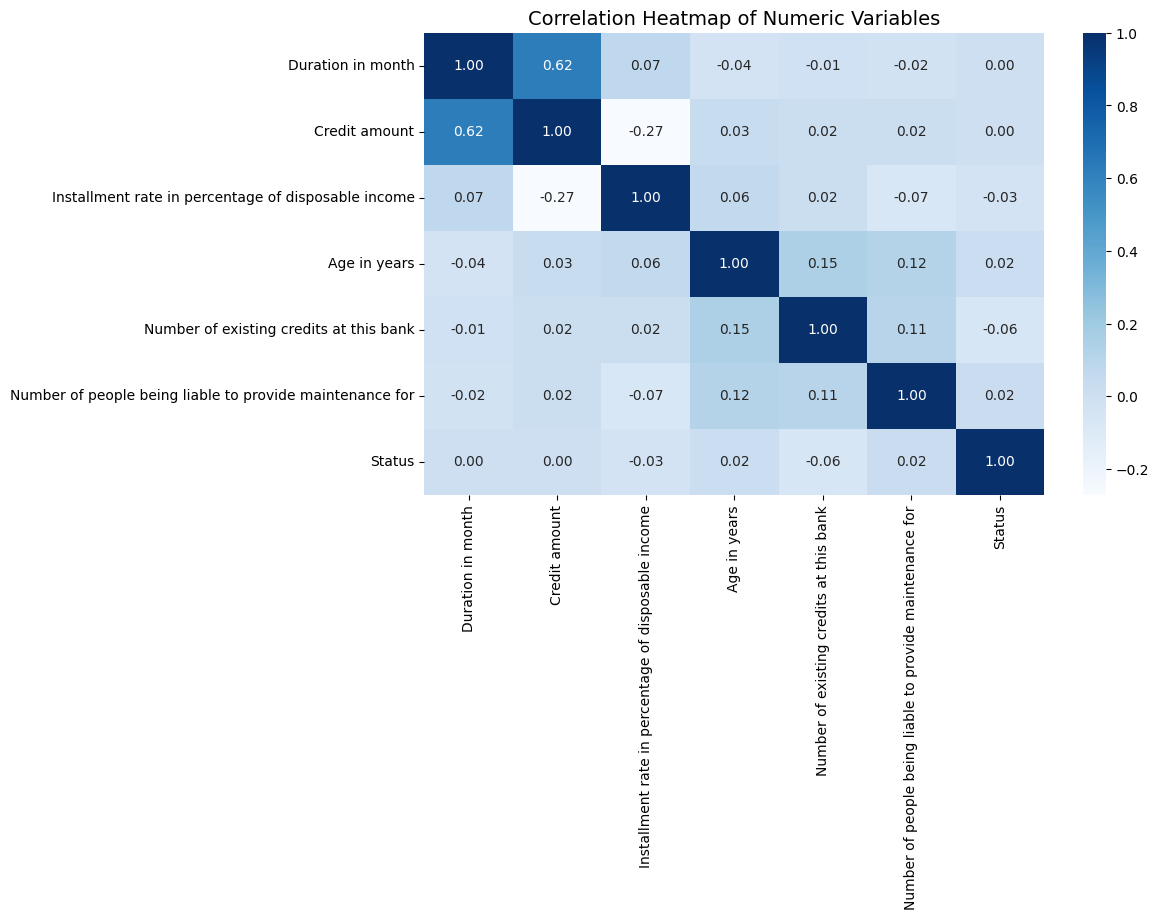

In [56]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)
plt.show()


/tmp/ipython-input-798377639.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Present employment since', y='Credit amount', data=data, palette='viridis')


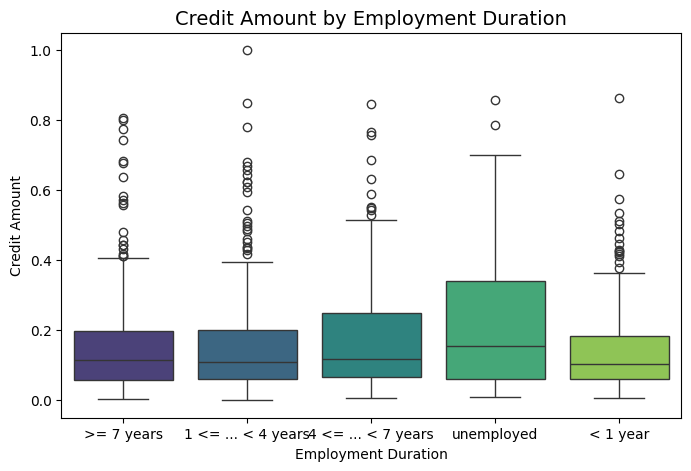

In [57]:
if 'Present employment since' in data.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Present employment since', y='Credit amount', data=data, palette='viridis')
    plt.title('Credit Amount by Employment Duration', fontsize=14)
    plt.xlabel('Employment Duration')
    plt.ylabel('Credit Amount')
    plt.show()


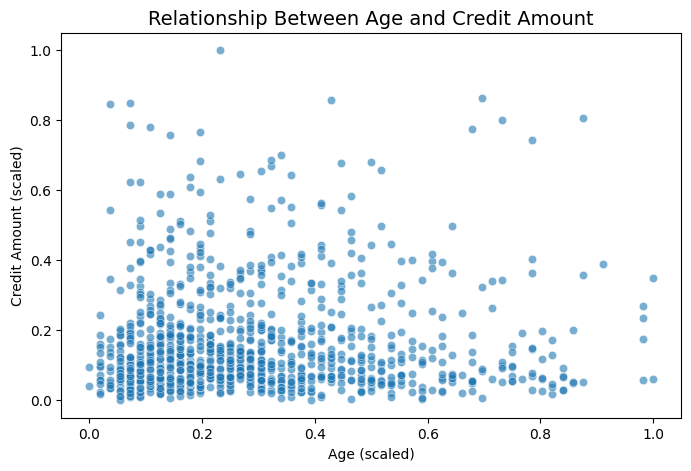

In [58]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age in years', y='Credit amount', data=data, alpha=0.6)
plt.title('Relationship Between Age and Credit Amount', fontsize=14)
plt.xlabel('Age (scaled)')
plt.ylabel('Credit Amount (scaled)')
plt.show()


# 📌 7. Checking and Handling Missing Values



In [59]:

# Handling missing values with SimpleImputer
imputer = SimpleImputer(strategy='mean')  # You can use other strategies like 'median' or 'most_frequent'

In [60]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Separate numeric and categorical columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(exclude=['int64', 'float64']).columns

# Imputer for numeric columns (mean)
num_imputer = SimpleImputer(strategy='mean')
data_num = pd.DataFrame(num_imputer.fit_transform(data[num_cols]), columns=num_cols)

# Imputer for categorical columns (most frequent)
cat_imputer = SimpleImputer(strategy='most_frequent')
data_cat = pd.DataFrame(cat_imputer.fit_transform(data[cat_cols]), columns=cat_cols)

# Combine back
data_imputed = pd.concat([data_num, data_cat], axis=1)


# 📌 8. Spliting Data into X and Y

---




In [61]:
X = data_imputed.drop(columns=['Status'])
y = data_imputed['Status']

# Apply one-hot encoding to the entire imputed dataset
X = pd.get_dummies(X)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#  9. Random Forest


In [63]:
#Initialise the rndom forest model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [64]:
#model training
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [65]:
#making predictions
y_pred = rf_classifier.predict(X_test)

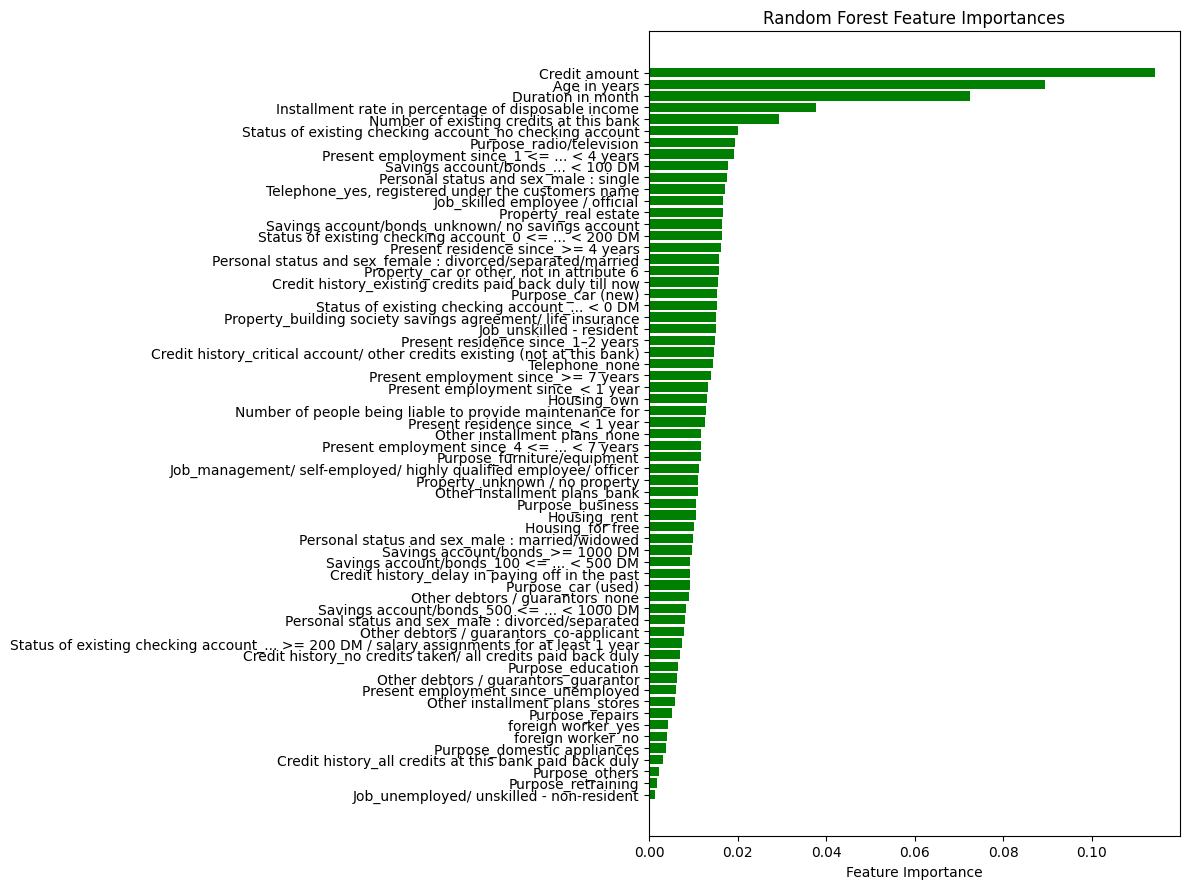

In [66]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming you have trained your Random Forest model as `rf_classifier` and your feature names in X.columns
importances = rf_classifier.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,9))
plt.barh(range(len(importances)), importances[indices], color='green')
plt.yticks(range(len(importances)), features[indices])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()  # highest importance at top
plt.tight_layout()
plt.show()

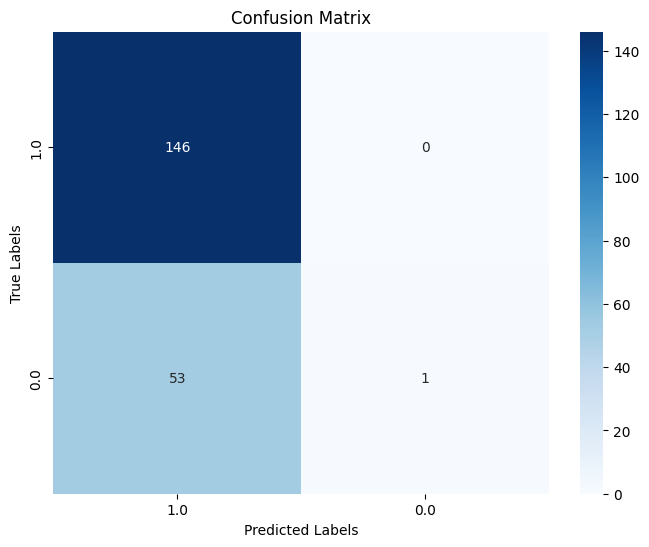

In [67]:
conf_matrix = confusion_matrix(y_test, y_pred, labels=y.unique())
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=y.unique(), yticklabels=y.unique())
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [68]:
from sklearn.metrics import classification_report
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.02      0.04        54
         1.0       0.73      1.00      0.85       146

    accuracy                           0.73       200
   macro avg       0.87      0.51      0.44       200
weighted avg       0.81      0.73      0.63       200



In [69]:
from sklearn.ensemble import RandomForestClassifier

In [70]:
forest = RandomForestClassifier()

In [71]:
forest.fit(X_train, y_train)

RandomForestClassifier()

In [72]:
from sklearn.metrics import accuracy_score
RandomForestClassifier=accuracy_score(y_test, y_pred)
RandomForestClassifier

0.735

Hyper Tuning for Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Base model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter search space
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Random search over hyperparameters
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=30,                # number of combinations to try
    cv=5,                     # 5-fold cross validation
    scoring='accuracy',       # or 'f1', 'recall', etc.
    n_jobs=-1,                # use all cores
    verbose=2,
    random_state=42
)

# Fit on training data
random_search.fit(X_train, y_train)

print("Best hyperparameters:")
print(random_search.best_params_)

# Best tuned model
best_rf = random_search.best_estimator_

# Evaluate on test data
y_pred = best_rf.predict(X_test)

print("\nAccuracy on test set:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits


#  10. Naive Bayes Classifier

---




In [ ]:
import matplotlib.pyplot as plt
import sklearn

In [ ]:
y_pred = forest.predict(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(X_train)
x_test = sc.transform(X_test)

In [ ]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

In [ ]:
y_predG  =  classifier.predict(X_test)

In [ ]:
y_predG

In [ ]:
y_test

In [ ]:
from sklearn.metrics import accuracy_score
Naive_Bayes=accuracy_score(y_test, y_predG)
Naive_Bayes

# Naive Bayes Classifier for hyper tunning

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

gnb = GaussianNB()

param_grid_gnb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_gnb = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid_gnb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_gnb.fit(X_train, y_train)

print("Best hyperparameters (GaussianNB):", grid_gnb.best_params_)

best_gnb = grid_gnb.best_estimator_
y_pred = best_gnb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


#  11. Decision tree classifier

---




In [ ]:
from sklearn import tree

In [ ]:
dtc = tree.DecisionTreeClassifier()

In [ ]:
dtc.fit(X_train, y_train)

In [ ]:
y_pred_decisiontree = dtc.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
DecisionTree=accuracy_score(y_test, y_pred_decisiontree)
DecisionTree

# Decision tree Classifier for hyper tunning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Simple hyperparameters to tune
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "criterion": ["gini", "entropy"]
}

# Grid search
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

# Best model
best_dt = grid.best_estimator_

# Prediction
y_pred = best_dt.predict(X_test)

# Accuracy
print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
